# **GEOL415 Lab 3**

Welcome to lab 3. This week will be a bit more free-form. 

**RECAP.** Last week, you:
- gained more experience with terminal commands.
- downloaded and properly imported tabular ice core data.
- analyzed said dataset.

**PREVIEW.** This week, you will:
- Look through a curated list of datasets provided to you by us.
- Select one you find interesting for your course project pitch next week.

As a reminder, this project will be:

**"...a data analysis report (5 pages single spaced, 0.5 inch margins, 12pt Arial font, at least 5 figures) and presentation on an earth and environmental science research topic. A grading rubric will be provided for the final project. The assignment is scaffolded throughout the semester with
intermediate due dates.'**

## **Select a dataset from the following options**
I will go through a couple of these with the class. Feel free to follow along or explore these on your own. 

# **Air Quality**

1. [EPA AQS pre-generated files](https://aqs.epa.gov/aqsweb/airdata/download_files.html) : hourly/daily pollutant concentrations from thousands of US monitors, by year and pollutant.

2. [OpenAQ](openaq.org) : global ground-station air quality data, API plus bulk archives. 

# **Weather/Climate**

1. [NOAA GHCN-Daily](https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.ncdc:C00861): daily temperature, precipitation, snowfall from tens of thousands of stations worldwide.

2. [Berkeley Earth land temperature data](https://berkeleyearth.org/data/): cleaned, gridded and station-level temperature records.

# **Hydrology**
1. [USGS NWIS](https://waterdata.usgs.gov/): streamflow, gauge height, water quality from thousands of US gauges.

2. [CAMELS](https://ral.ucar.edu/dataset/camels-catchment-attributes-and-meteorology-large-sample-studies-dataset-downloads): 671 US catchments with matched streamflow and meteorological forcing


 # **Ecology and biodiversity**
1. [GBIF](https://www.gbif.org/): hundreds of millions of species occurrence records, simple download and filter interface.

2. [eBird Basic Dataset](https://science.ebird.org/use-ebird-data/download-ebird-data-products): citizen-science bird sightings with location, date, observer effort.

3. [GRooT](https://groot-database.github.io/GRooT/): global root trait database compiling measurements across thousands of plant species.


# **Land cover and remote sensing**

1. [ESA WorldCover](https://esa-worldcover.org/en): global 10m land cover classification, accessible through Google Earth Engine.
2. [NASA FIRMS active fire data](https://firms.modaps.eosdis.nasa.gov/active_fire/): daily fire detections

# **Ocean and marine**
1. [NOAA National Data Buoy Center](https://www.ndbc.noaa.gov/): hourly wind, wave, and temperature observations from moored buoys.
2. [Argo float profiles](https://argo.ucsd.edu/): temperature and salinity profiles from autonomous floats, with the ```argopy``` package for querying.


# **Deliverable for today's lab**

1. Write down which dataset you chose to work with in a markdown cell below. 
2. Load up a pd.DataFrame of a dataset of your choosing.
3. Give me **ONE** summary statistic, visualization, etc. of the data.

**If you already have data to work with**: Do 1-3 with that.

I want to work with one of the climate model dataset like CESM PlioMIP2 Project/TraCE-21Ka/iCESM models. I'm mot sure yet, I need some time to decide. For now, I've downloaded the CESM PlioMIP2 Atmosphere Monthly Files.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import xarray as xr
import cartopy.crs as ccrs

In [2]:
ds = xr.open_dataset("b.e12.B1850C5CN.f09_g16.preind.cam.h0.PRECC.050101-055012.nc")

In [3]:
ds

<xarray.Dataset> Size: 133MB
Dimensions:       (lev: 30, ilev: 31, slat: 191, lat: 192, time: 600, nbnd: 2,
                   lon: 288, slon: 288)
Coordinates:
  * lev           (lev) float64 240B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 248B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * slat          (slat) float64 2kB -89.53 -88.59 -87.64 ... 87.64 88.59 89.53
  * lat           (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * time          (time) object 5kB 0501-02-01 00:00:00 ... 0551-01-01 00:00:00
  * lon           (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * slon          (slon) float64 2kB -0.625 0.625 1.875 ... 355.6 356.9 358.1
Dimensions without coordinates: nbnd
Data variables: (12/32)
    hyam          (lev) float64 240B ...
    hybm          (lev) float64 240B ...
    hyai          (ilev) float64 248B ...
    hybi          (ilev) float64 248B ...
    P0            float64 8B ...
    w_stag        (slat) float64 2kB ...
    ...            ...
    n2ovmr        (time) float64 5kB ...
    f11vmr        (time) float64 5kB ...
    f12vmr        (time) float64 5kB ...
    sol_tsi       (time) float64 5kB ...
    nsteph        (time) int32 2kB ...
    PRECC         (time, lat, lon) float32 133MB ...
Attributes:
    Conventions:      CF-1.0
    source:           CAM
    case:             b.e12.B1850C5CN.f09_g16.preind
    title:            UNSET
    logname:          ranfeng
    host:             ys0629
    Version:          $Name$
    revision_Id:      $Id$
    initial_file:     b.e11.B1850C5CN.f09_g16.005.cam.i.0501-01-01-00000.nc
    topography_file:  /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/USGS-gtop...

/opt/anaconda3/envs/geol415/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/geol415/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


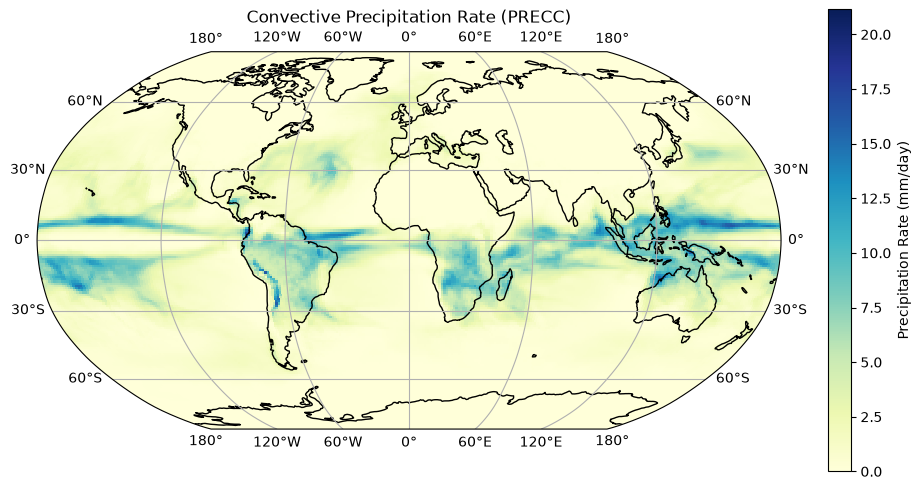

In [4]:
precc_mm_day = ds['PRECC'] * 86400000

precc_slice = precc_mm_day.isel(time=0)

plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())

plot = precc_slice.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(), 
    cmap='YlGnBu', 
    cbar_kwargs={'label': 'Precipitation Rate (mm/day)'}
)

ax.coastlines()
ax.gridlines(draw_labels=True)
plt.title('Convective Precipitation Rate (PRECC)')
plt.show()